# Lag effect Analysis

### "정책 효과가 강하게 나타난 시점일수록, 모델은 더 쉽게 결과(Y)를 예측할 수 있다"
1. 정책이 효과를 발휘하면, Y(조직성과/개인결과)가 X(정책포함 정보)에 더 강하게 종속된다.
- 정책 도입 전에는 조직성과(Y)가 다양한 외적 요인에 따라 들쭉날쭉 (예측 어려움).
- 정책이 효과를 발휘하면 → 특정 정책 조건(X)에 따라 Y가 더 일관되고 예측 가능하게 변화함.
- 즉, 정책이 Y에 설명력을 부여한다.

2. 모델은 설명력 높은 관계일수록 예측 성능이 높다.
- 머신러닝 모델의 본질: 입력 X와 출력 Y 사이의 규칙성을 찾아내는 것.
- 따라서, 만약 정책 효과로 인해 X (정책포함) → Y의 인과 경로가 강해졌다면,
- 모델은 더 쉽게 일반화 가능한 패턴을 학습함.
- 결과적으로, 정확도, F1, AUC 등의 성능이 높아짐.

1. Stage 1
    - 2020년 데이터 X + 2021년 데이터 y => 모델-2020_2021
    - 2020년 데이터 X + 2023년 데이터 y => 모델-2020_2023
    => 각 모델의 퍼포먼스 측정 (강한 예측력을 보이는 모델 = 그게 결국 영향력)
    => 각 모델 해석력 지수 얻기 / 중요도에 따라서 인풋값의 가중치 다르게 줌


2. Stage 2
    - 2021년 데이터 X + 2021년 데이터 y => 모델-2021_2021
    - 2021년 데이터 X + 2023년 데이터 y => 모델-2022_2023

3. Stage 3
    - 2022년 데이터 X + 2023년 데이터 y => 모델-2022_2023

4. Stage 4
    - 2023년 데이터 X + 2023년 데이터 y => 모델-2023_2023

---

- Head말고 Work데이터를 봐야함
- Dataset: 2020 / 2021 / 2022 / 2023
- Y : Target label
    W20Q09A / W21Q09A / W22Q09A / ...

- X
    - 직원들 같은거로 하면 동일한거 거의 없음
    - 같은 회사일 필요도 없는듯

In [1]:
import matplotlib.pyplot as plt
import utils_, config, model
import os
import numpy as np
import pandas as pd
import Analysis_function
import preprocess

import warnings
warnings.filterwarnings('ignore')

# 1. Fetch dataset in dict format - Work data / Head data
dataset_Work_original = preprocess.get_all_data(config.year_list, config.file_names_Work)
dataset_Head = preprocess.get_all_data(config.year_list, config.file_names_Head)

# 2. Check the every column and its semantic name
#utils_.see_col_idx_and_name(dataset['2020']['data'], dataset['2020']['meta'])

# 3. Check the intersection for the number of organization - year by year (e.g. compare 2020 - 2021)
#_ = Analysis_function.compare_company_ids_in_dataset(dataset_Work)

# 4. Check the intersection for the number of organization - All years (2020-2023) - we do this again in next step
#_ = Analysis_function.get_common_company_ids_all_years(dataset_Work)

# 5. Check the intersection for the number of organization (All) and filter; select only the organization that involves throughout all years
dataset_Work = preprocess.filter_dataset_by_common_ids(dataset_Work_original)

# 6. Target variable check - 1. Type count (value_counts()) / 2. check Nan
Analysis_function.target_variable_check(dataset_Work, target_variable=config.target_col)

# 7. Store only the common columns in each yearly dataset - 컬럼이 다르면 안되니깐.
dataset_Work = preprocess.unify_columns_by_base_name(dataset_Work)

# 8. Nan 값 25% 언더면 정수형 평균값으로 넣고, 위면 해당 컬럼 삭제
dataset_Work = preprocess.clean_all_years(dataset_Work, columns_to_drop=[], verbose=True)

C:\Users\hml76\PycharmProjects\HRD2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HCCP_2ndWave_Work_1st_v2.sav ===> 2020 data
HCCP_2ndWave_Work_2nd_v2.sav ===> 2021 data
HCCP_2ndWave_Work_3rd_v3.sav ===> 2022 data
HCCP_2ndWave_Work_4th.sav ===> 2023 data
HCCP_2ndWave_Head_1st(최종).sav ===> 2020 data
HCCP_2ndWave_Head_2nd(최종).sav ===> 2021 data
HCCP_2ndWave_Head_3rd(최종).sav ===> 2022 data
HCCP_2ndWave_Head_4th.sav ===> 2023 data
공통 기업 ID 개수: 384
2020 필터링 후 행 개수: 7054
2021 필터링 후 행 개수: 7613
2022 필터링 후 행 개수: 7338
2023 필터링 후 행 개수: 8740
2020 - W20Q09A : NaN 0개 / 전체 7054개 (0.00%)
W20Q09A
3.0    2372
8.0    1682
4.0    1534
2.0     873
5.0     434
1.0     159
Name: count, dtype: int64
2021 - W21Q09A : NaN 0개 / 전체 7613개 (0.00%)
W21Q09A
-8.0    2331
 3.0    2318
 4.0    1511
 2.0     907
 5.0     369
 1.0     177
Name: count, dtype: int64
2022 - W22Q09A : NaN 0개 / 전체 7338개 (0.00%)
W22Q09A
3.0    2263
8.0    1922
4.0    1436
2.0     893
5.0     501
1.0     323
Name: count, dtype: int64
2023 - W23Q09A : NaN 0개 / 전체 8740개 (0.00%)
W23Q09A
3.0    4008
4.0    2034
2.0    1133
5.0   

In [2]:
for year in ['2020', '2021', '2022', '2023']:
    if year == '2021' or '2023':
        if year == '2021':
            # Merge data - Work (X) + Head (y)
            df1, label_col1 = preprocess.merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2021')
            df2, label_col2 = preprocess.merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2023')

            # Clean y data - i) erase labels 3/8/-8 and transform 1,2 -> 0 / 4,5 -> 1    ii) remove y from X
            df_21_21, y_21_21 = preprocess.clean_target_classes(df1, target_col=label_col1)
            df_21_23, y_21_23 = preprocess.clean_target_classes(df2, target_col=label_col2)
            print("\t", df_21_21.shape, y_21_21.shape)#, pd.Series(y_21_21).value_counts())
            print("\t", df_21_23.shape, y_21_23.shape)#, pd.Series(y_21_23).value_counts())

        elif year == '2023':
            df1, label_col1 = preprocess.merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2023')
            df_23_23, y_23_23 = preprocess.clean_target_classes(df1, target_col=label_col1)
            print("\t", df_23_23.shape, y_23_23.shape)#, pd.Series(y_23_23).value_counts())

    if year == '2020' or '2022':
        if year == '2020':
            df1, label_col1 = preprocess.merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2021')
            df2, label_col2 = preprocess.merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2023')
            df_20_21, y_20_21 = preprocess.clean_target_classes(df1, target_col=label_col1)
            df_20_23, y_20_23 = preprocess.clean_target_classes(df2, target_col=label_col2)
            print("\t", df_20_21.shape, y_20_21.shape)#, pd.Series(y_20_21).value_counts())
            print("\t", df_20_23.shape, y_20_23.shape)#, pd.Series(y_20_23).value_counts())


        elif year == '2022':
            df1, label_col1 = preprocess.merge_worker_head_labels(dataset_Work, dataset_Head, year_w=year, year_h='2023')
            df_22_23, y_22_23 = preprocess.clean_target_classes(df1, target_col=label_col1)
            #print("\t", df_22_23.shape, y_22_23.shape)#, pd.Series(y_22_23).value_counts())


Year: 2020 | Merged shape: (7054, 110) | work shape: (7054, 127) | head shape: (500, 2)
Year: 2020 | Merged shape: (7054, 110) | work shape: (7054, 127) | head shape: (500, 2)
	 (1918, 109) (1918,)
	 (1697, 109) (1697,)
Year: 2021 | Merged shape: (7613, 111) | work shape: (7613, 128) | head shape: (500, 2)
Year: 2021 | Merged shape: (7613, 111) | work shape: (7613, 128) | head shape: (500, 2)
	 (1989, 110) (1989,)
	 (1640, 110) (1640,)
Year: 2022 | Merged shape: (7338, 123) | work shape: (7338, 141) | head shape: (500, 2)
Year: 2023 | Merged shape: (8740, 109) | work shape: (8740, 126) | head shape: (500, 2)
	 (2094, 108) (2094,)


HCCP_2ndWave_Work_1st_v2.sav ===> 2020 data
HCCP_2ndWave_Work_2nd_v2.sav ===> 2021 data
HCCP_2ndWave_Work_3rd_v3.sav ===> 2022 data
HCCP_2ndWave_Work_4th.sav ===> 2023 data

🧪 Processing: 2020 ➝ 2021
Original class distribution:
1.0    1247
0.0     671
Name: count, dtype: int64
Resampled class distribution:
0.0    988
1.0    988
Name: count, dtype: int64
XGBoost Accuracy ========>  77.34375 %

📌 Top 10 Feature Importances:
W20SCALE: 기업규모
W20Q083D: (4)주요고객 유지율
W20Q081A: (1)인적자원의 전반적인 역량
W20Q29: 노동조합 조합원 가입 여부
W20Q15C1: (3)직원들 개개인 간의 지식 및 노하우 공유_비공식적 학습 방법 참여 여부
W20IND1: 산업분류
W20Q23A: (1)우수한 인재를 우대하고 있다
W20Q15B1: (2)상사에 의한 코칭 및 멘토링_비공식적 학습 방법 참여 여부
W20Q25E: (5)인화단결과 일체감을 중시한다
W20Q11A1: 직무간 훈련_교육훈련 참여 여부


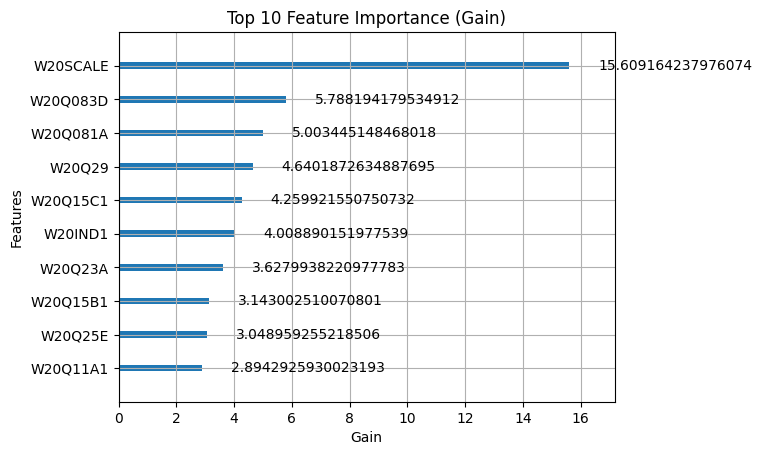


🧪 Processing: 2020 ➝ 2023
Original class distribution:
1.0    1388
0.0     309
Name: count, dtype: int64
Resampled class distribution:
1.0    1110
0.0    1110
Name: count, dtype: int64
XGBoost Accuracy ========>  88.52941176470588 %

📌 Top 10 Feature Importances:
W20Q081E: (5)종업원 생산성
W20Q083B: (2)제품의 다양성
W20Q10B: (2)관리자 교육훈련
W20DQ03: 혼인상태
W20Q11A1: 직무간 훈련_교육훈련 참여 여부
W20Q12C: (3)유지보수훈련
W20Q083C: (3)신규고객 확보율
W20Q15D1: (4)사내 플랫폼을 통한 지식 공유_비공식적 학습 방법 참여 여부
W20Q28: 정규직 여부
W20Q22A: (1)조직의 조직원들은 문제해결 및 의사결정에 적극적으로 참여한다


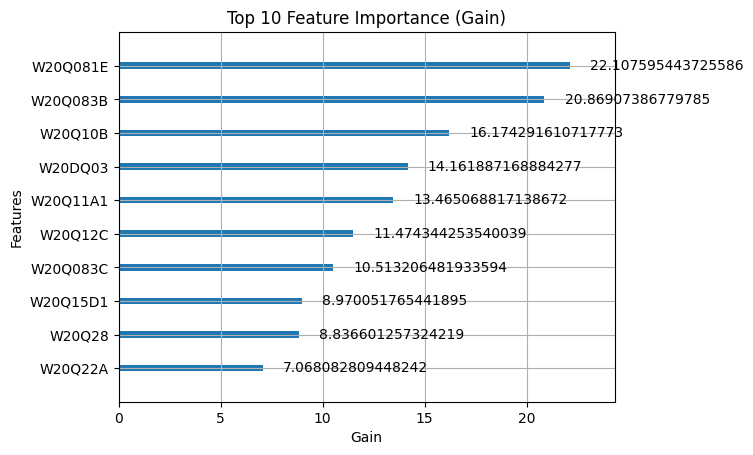


🧪 Processing: 2021 ➝ 2021
Original class distribution:
1.0    1280
0.0     709
Name: count, dtype: int64
Resampled class distribution:
1.0    1002
0.0    1002
Name: count, dtype: int64
XGBoost Accuracy ========>  72.61306532663316 %

📌 Top 10 Feature Importances:
W21SCALE: 기업규모
W21Q11B1: 집합 훈련_교육훈련 참여 여부
W21Q082D: (4)제품의 품질
W21Q11A1: 직무간 훈련_교육훈련 참여 여부
W21Q14A: (1)교육훈련이 충분하게 이루어지고 있다
W21Q16D1: (4)해외 대학원 학위과정 지원 제도_2019년 자기주도적 학습 지원 제도 참여 여부
W21IND1: 산업분류
W21Q082E: (5)불량률 감소 및 생산수율 향상
W21Q25H: (8)의사전달이나 정보 흐름은 하향식이다
W21Q11A2: 직무간 훈련_교육훈련 참여가 직무능력에 미친 효과


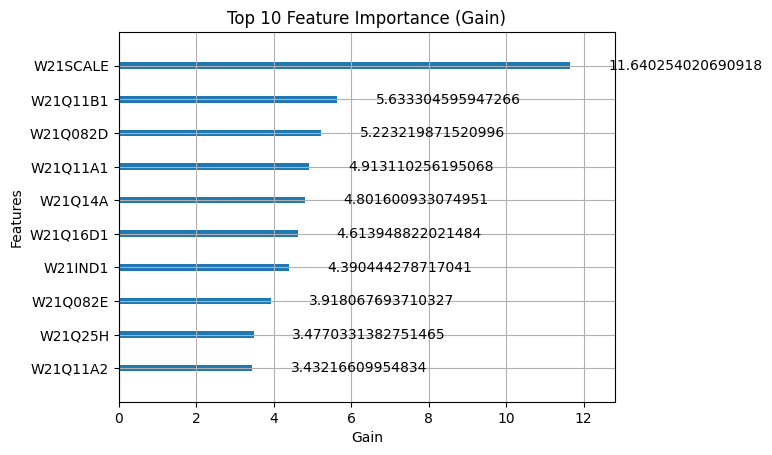


🧪 Processing: 2021 ➝ 2023
Original class distribution:
1.0    1298
0.0     342
Name: count, dtype: int64
Resampled class distribution:
0.0    1038
1.0    1038
Name: count, dtype: int64
XGBoost Accuracy ========>  84.7560975609756 %

📌 Top 10 Feature Importances:
W21Q083B: (2)제품의 다양성
W21Q11A1: 직무간 훈련_교육훈련 참여 여부
W21Q15B1: (2)상사에 의한 코칭 및 멘토링_비공식적 학습 방법 참여 여부
W21Q15C1: (3)직원들 개개인 간의 지식 및 노하우 공유_비공식적 학습 방법 참여 여부
W21Q083A: (1)고객요규에 대한 신속한 대응능력
W21Q24C: (3)부서간의 커뮤니케이션이 잘 되는 편이다
W21Q082D: (4)제품의 품질
W21Q12C: (3)유지보수훈련
W21Q25D: (4)가족과 같은 조직 분위기가 형성되어 있다
W21IND1: 산업분류


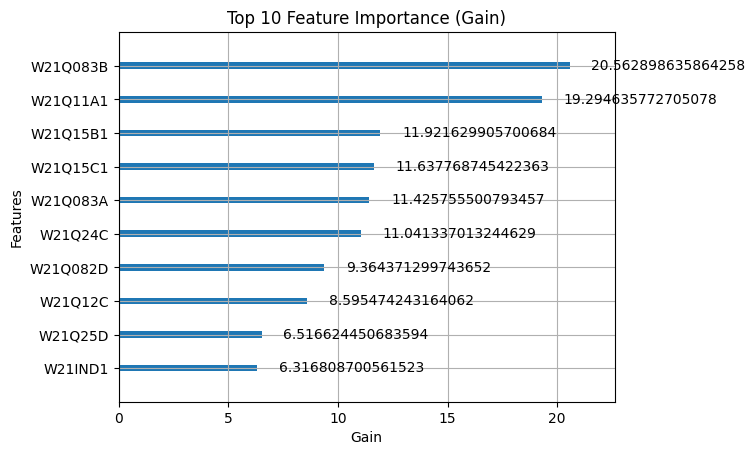


🧪 Processing: 2022 ➝ 2023
Original class distribution:
1.0    1330
0.0     274
Name: count, dtype: int64
Resampled class distribution:
1.0    1064
0.0    1064
Name: count, dtype: int64
XGBoost Accuracy ========>  89.40809968847351 %

📌 Top 10 Feature Importances:
W22Q12A: (1)직무능력 향성
W22Q24C: (3)부서간의 커뮤니케이션이 잘 되는 편이다
W22Q16C1: (3)국내 대학원 등록금 지원 제도_2019년 자기주도적 학습 지원 제도 참여 여부
W22Q083B: (2)제품의 다양성
W22DQ03: 혼인상태
W22Q14F: (6)교육훈련 내용은 범용적이다
W22Q081E: (5)종업원 생산성
W22IND1: 산업분류
W22Q29: 노동조합 조합원 가입 여부
W22Q082E: (5)불량률 감소 및 생산수율 향상


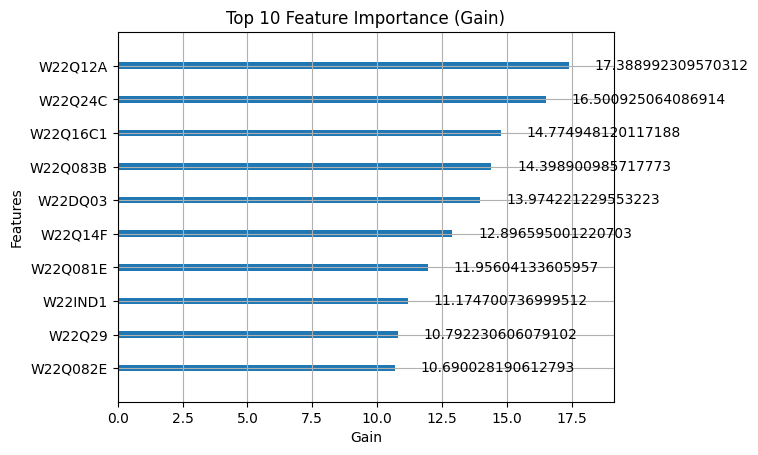


🧪 Processing: 2023 ➝ 2023
Original class distribution:
1.0    1489
0.0     605
Name: count, dtype: int64
Resampled class distribution:
1.0    1186
0.0    1186
Name: count, dtype: int64
XGBoost Accuracy ========>  91.40811455847255 %

📌 Top 10 Feature Importances:
W23Q082E: (5)불량률 감소 및 생산수율 향상
W23Q083E: (5)브랜드 이미지 향상 및 관리
W23Q12C: 유지보수 훈련
W23Q11A1: 직무간 훈련_교육훈련 참여 여부
W23Q301: 2021년 주당 정규 근로시간
W23Q083B: (2)제품의 다양성
W23Q083C: (3)신규고객 확보율
W23Q22E: 두 가지 이상의 업무를 수행할 수 있는 능력을 갖춤
W23SCALE: 기업규모
W23Q11B1: 집합 훈련_교육훈련 참여 여부


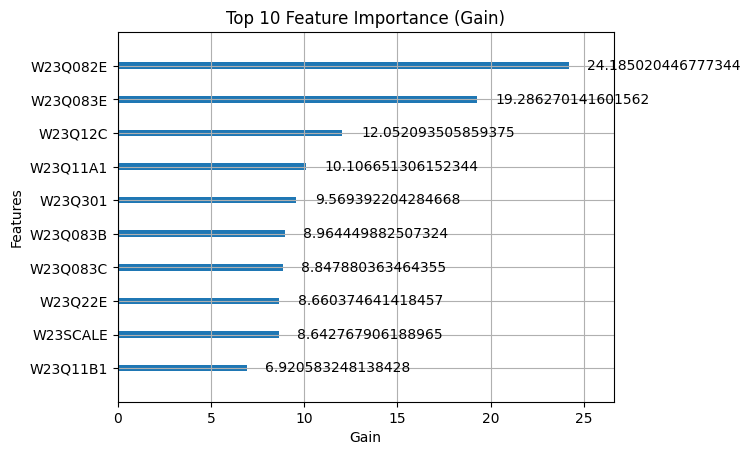

In [3]:
# Define the datasets and their labels
dataset_pairs = {
    "2020 ➝ 2021": (df_20_21, y_20_21),
    "2020 ➝ 2023": (df_20_23, y_20_23),
    "2021 ➝ 2021": (df_21_21, y_21_21),
    "2021 ➝ 2023": (df_21_23, y_21_23),
    "2022 ➝ 2023": (df_22_23, y_22_23),
    "2023 ➝ 2023": (df_23_23, y_23_23),
}

# Store accuracies
acc_dict = {}

dataset_Work_init = preprocess.get_all_data(config.year_list, config.file_names_Work)

# Evaluate and store
for desc, (X, y) in dataset_pairs.items():
    acc, XGBoost_model = model.train_evaluate_model(X, y, description=desc, learning_graph_show=False)

    # Extract meta based on the first year in the desc
    year_prefix = desc[:4]  # e.g., '2020'
    meta = dataset_Work[year_prefix]['meta']

    # Use updated feature_importance function
    model.feature_importance(XGBoost_model, X, dataset_Work_init[desc[:4]]['data'], dataset_Work_init[desc[:4]]['meta'])

    acc_dict[desc] = acc


In [6]:
import utils_
utils_.see_col_idx_and_name(dataset_Work_original['2020']['data'], dataset_Work['2020']['meta'])

W20Q081E 기업id
W20Q25I 근로자id
W20Q15B2 기업&근로자id
W20Q15A1 산업분류
W20Q14F 기업규모
W20Q15E2 회사 입사 년도_년
W20Q15C2 회사 입사 년도_월
W20Q082B 현재 직급 근무 시작 년도_년
W20Q05A 현재 직급 근무 시작 년도_월
W20Q25C 입사당시 직급
W20Q14E 현재 직급
W20Q15A2 주 업무
W20Q27G 현재 맡고 있는 업무 시작 년도_년
W20Q27F 현재 맡고 있는 업무 시작 년도_월
W20Q15C1 (1)경영전략계획 수립과정에 중요한 공헌을 함
W20Q18A (2)최고경영자의 의사결정에 중대한 영향을 미침
W20Q09E (3)인사제도의 지속적 개선과 실행을 위해 주도적인 역할을 함
W20Q25J (4)회사의 변화와 혁신을 주도 함
W20Q15D1 (1)인사 관련 이슈에 대해 현업 부서장들을 교육하고 조언을 제공 함
W20Q22F (2)인사제도의 내용을 수시로 직원들에게 설명해 줌
W20Q03B (3)회사 직원들로부터 신뢰를 받음
W20Q31A (4)해당분야에 상당한 전문성을 가짐
W20Q26B HR업무 담당인력의 전문성
W20Q14A (1)인적자원의 전반적인 역량
W20DQ04 (2)우수인력의 확보
W20Q01B (3)신뢰를 바탕으로 한 공동체 형성
W20Q05B (4)경영진의 리더십
W20Q062A (5)종업원 생산성
W20Q16A2 (1)신제품 개발능력
W20Q18B (2)업무절차의 효율화 간소화
W20Q26A (3)제품의 원가절감을 통한 경쟁우위의 확보
W20Q07 (4)제품의 품질
W20Q15D2 (5)불량률 감소 및 생산수율 향상
W20Q061A (1)고객요규에 대한 신속한 대응능력
W20Q25A (2)제품의 다양성
W20Q14D (3)신규고객 확보율
W20Q27D (4)주요고객 유지율
W20Q10D (5)브랜드 이미지 향상 및 관리
W20Q11B1 인력에 대한 분야별 경쟁력 수준 평가_연구개발인력
W20Q14B 인력에 대한 분야별 경쟁력 수준 평가_영업 및 서비스인

In [6]:

model_20_21, imp_20_21 = model.train_and_analyze_one_feature(df_20_21, y_20_21, label="2020_2021")
model_20_23, imp_20_23 = model.train_and_analyze_one_feature(df_20_23, y_20_23, label="2020_2023")
model_21_21, imp_21_21 = model.train_and_analyze_one_feature(df_21_21, y_21_21, label="2021_2021")
model_21_23, imp_21_23 = model.train_and_analyze_one_feature(df_21_23, y_21_23, label="2021_2023")

print("\nPolicy-related feature importance by year:")
for year, imp in zip(['2020', '2020', '2021', '2021'], [imp_20_21, imp_20_23, imp_21_21, imp_21_23]):
    val = imp.query(f"feature == 'W{year[2:]}Q10B'")['importance'].values
    print(f"{year}: {val[0] if len(val) > 0 else 'Not Found'}")


📊 Policy-related feature importance by year:
2020: 0.002245148876681924
2020: 0.00823393277823925
2021: 0.0034610817674547434
2021: 0.0002336237666895613


1. 지금 Lag effect는 끝남 - 성능 좋음 - 쓸거있음
2. 이제 해석력 부분 집중
3. 해석력 기반으로 다음 년도에 어떻게 넘길지도 고민해보기 - Weighted RandoForest 뭐 이런거 주던지 (Knowledge transfer 부분)
4. 여러 모델 가지고 Weighted Voting 같은걸로 성능 살짝 올려보기 혹은 유지한다고 썰풀기 (가장 오래된 모델이 좋다고 되니깐 좋은 순으로 weight 주기 - 네모  model A/B/C .. 에서 어떻게 prediction으로 나갈까 부분)



'''W20ID1 기업id
W20ID2 근로자id
W20ID3 기업&근로자id
W20IND1 산업분류'''

헤드데이터로 representative 레이블링을 준다!